In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fftpack import fft2, ifft2
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import time

import glob, random, scipy.io
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd
import os
from scipy.signal import medfilt, medfilt2d
from scipy.io import loadmat

from scipy.optimize import fsolve
import math
from sympy.solvers import solve
from sympy import Symbol
import datetime
import copy
from scipy.interpolate import interp2d

from scipy.optimize import curve_fit
import B00_codes.dataReader as dr

NO_MS_EQUALS_1 = 0
Q_FINAL = 1
THREE_PI_HALF_FINAL = 2
REF_MINUS_SIG  =3

def smooth(x, n=3):
    K = int((n-1)/2)
    smoothed_x = np.zeros(len(x))
    for i in range(K):
        smoothed_x[i] = x[i]
        smoothed_x[-i-1] = x[-i-1]
    for i in range(0, len(x)-(n-1)):
        for j in range(n):
            smoothed_x[i+K] += x[i+j]/n
    return smoothed_x

def find_peaks(data, threshold=0):
    peaks = []
    for i in range(1, len(data) - 1):
        if data[i] > data[i - 1] and data[i] > data[i + 1] and data[i] > threshold:
            peaks.append(i)
    return peaks

def average(y, n):
    # Initialize an empty list to store the averages
    averages = []

    # Iterate through the array in steps of 3
    for i in range(0, len(y), n):
        group = y[i:i + n]  # Get a group of three points
        average = np.mean(group)  # Calculate the average of the group
        averages.append(average)  # Add the average to the list

    # Convert the list of averages back to a NumPy array
    return np.array(averages)
pi = np.pi
def chi_squared(y, y_fit, sigma):
    residuals = y - y_fit
    return np.sum((residuals / sigma)**2)

def reduced_chi_squared(y, y_fit, sigma, popt, pcov):
    n = len(y)  # Number of data points
    p = len(popt)  # Number of fitting parameters
    dof = n - p  # Degrees of freedom
    chisq = chi_squared(y, y_fit, sigma)  # Chi-squared value
    reduced_chisq = chisq / dof
    return reduced_chisq

# Physics constants
pi = np.pi
ee = 1.60217662e-19
h = 6.62607004e-34
hbar = h / 2/pi
epsilon = 8.854e-12
gamma = 2.87e10  # Hz per Tesla
me = 9.10938356e-31
phi0=h/2/ee
u0 = 4*pi*1e-7   #permativity of vacuum
kb = 1.380649e-23

# Define functions

In [2]:
def FFT2D_Mat_wrapper(x_axis, y_axis, signal, Type):
    Nx = len(x_axis)
    oddx = Nx % 2
    Ny = len(y_axis)
    oddy = Ny % 2

    if Type == 1:
        dx = x_axis[1] - x_axis[0]
        dy = y_axis[1] - y_axis[0]
        dfx = 1 / (Nx * dx)
        dfy = 1 / (Ny * dy)

        if oddx == 0:  # is even
            fx = np.arange(-Nx / 2, Nx / 2) * dfx
            vexKx = 2 * np.pi * fx
        else:  # is odd
            fx = np.arange(-(Nx - 1) / 2, (Nx - 1) / 2 + 1) * dfx
            vexKx = 2 * np.pi * fx

        if oddy == 0:  # is even
            fy = np.arange(-Ny / 2, Ny / 2) * dfy
            vexKy = 2 * np.pi * fy
        else:  # is odd
            fy = np.arange(-(Ny - 1) / 2, (Ny - 1) / 2 + 1) * dfy
            vexKy = 2 * np.pi * fy

        FFTout = np.fft.fftshift(np.fft.fft2(signal)) * dx * dy
#         print(FFTout)
#         print('-------')
        kkx, kky = np.meshgrid(vexKx, vexKy)
        phaseTerm = np.exp(-1j * (kkx * x_axis[0] + kky * y_axis[0]))
        Signal_tr = FFTout * phaseTerm

    else:
        dx = x_axis[1] - x_axis[0]
        dy = y_axis[1] - y_axis[0]
        dfx = 1 / (Nx * dx)
        dfy = 1 / (Ny * dy)

        if oddx == 0:  # is even
            fx = np.arange(-Nx / 2, Nx / 2) * dfx
            vexKx = 2 * np.pi * fx
        else:  # is odd
            fx = np.arange(-(Nx - 1) / 2, (Nx - 1) / 2 + 1) * dfx
            vexKx = 2 * np.pi * fx

        if oddy == 0:  # is even
            fy = np.arange(-Ny / 2, Ny / 2) * dfy
            vexKy = 2 * np.pi * fy
        else:  # is odd
            fy = np.arange(-(Ny - 1) / 2, (Ny - 1) / 2 + 1) * dfy
            vexKy = 2 * np.pi * fy

        dx1 = 1 / (vexKx[1] - vexKx[0])
        dy1 = 1 / (vexKy[1] - vexKy[0])
        kkx, kky = np.meshgrid(x_axis, y_axis)
        phaseTerm = np.exp(-1j * (kkx * vexKx[0] + kky * vexKy[0]))
        FFTout = (np.fft.ifft2(np.fft.ifftshift(signal * phaseTerm)) * dx1 * dy1)
        Signal_tr = FFTout

    return vexKx, vexKy, Signal_tr

In [3]:
def Reconstruction_StrayOUTpl_v2(Xaxis, Yaxis, BParMap, thetaNV, phiNV):
    # Define thetaNV
    # thetaNV = -np.arccos(1/np.sqrt(3))
    
    # Step 1: FFT OF THE SPIN STRUCTURE
    rx, ry = np.meshgrid(Xaxis, Yaxis)
    vexKx, vexKy, BParMap_k = FFT2D_Mat_wrapper(rx[0], ry[:, 0], BParMap, 1)
#     print(vexKx[vexKx==0])

    # Step 2: Define filter function
    kXres, kYres = np.meshgrid(vexKx, vexKy)
    Ktot = np.sqrt(kXres**2 + kYres**2)
    FfactX = 1j * (kXres / Ktot)  # i*cos
    FfactY = 1j * (kYres / Ktot)  # i*sin
#     np.logical_and(vexKy == 0, vexKx == 0)
#     FfactX[np.logical_and(vexKy == 0, vexKx == 0)] = 0
#     FfactY[np.logical_and(vexKy == 0, vexKx == 0)] = 0
    FfactX[vexKy == 0, vexKx == 0] = 0
    FfactY[vexKy == 0, vexKx == 0] = 0

    # Filter function
    Bperp_map_k = BParMap_k * (1 / (np.cos(thetaNV) - np.sin(thetaNV) * np.cos(phiNV) * FfactX - 
                                    np.sin(thetaNV) * np.sin(phiNV) * FfactY))
#     print(BParMap_k)

    Bperp_map_k_X = -Bperp_map_k * FfactX
    Bperp_map_k_Y = -Bperp_map_k * FfactY

    # Step 3: Invert back
    rx_inv, ry_inv, Bperp_map = FFT2D_Mat_wrapper(vexKx, vexKy, Bperp_map_k, 0)
    _, _, BX = FFT2D_Mat_wrapper(vexKx, vexKy, Bperp_map_k_X, 0)
    _, _, BY = FFT2D_Mat_wrapper(vexKx, vexKy, Bperp_map_k_Y, 0)
    Bperp_map = np.real(Bperp_map)
    BX = np.real(BX)
    BY = np.real(BY)

    return rx_inv, ry_inv, Bperp_map, BX, BY

In [4]:
def Recreate_m_inplane_from_field(Xaxis, Yaxis, BMap, height, thetaNV, phiNV, thickness):
    # Step 1: FFT of the NV field map
    rx, ry = np.meshgrid(Xaxis, Yaxis)
    vexKx, vexKy, BMap_k = FFT2D_Mat_wrapper(rx[0, :], ry[:, 0], BMap, 1)

    # Step 2: Define filter function
    kXres, kYres = np.meshgrid(vexKx, vexKy)
    Ktot = np.sqrt(kXres**2 + kYres**2)
    FfactX = 1j * (kXres / Ktot)  # i*cos
    FfactY = 1j * (kYres / Ktot)  # i*sin
    FfactX[vexKy == 0, vexKx == 0] = 0
    FfactY[vexKy == 0, vexKx == 0] = 0

    # Coefficient for conversion field to M
    Bcoeff = 1 / (np.cos(thetaNV) - np.sin(thetaNV) * np.cos(phiNV) * FfactX - 
                  np.sin(thetaNV) * np.sin(phiNV) * FfactY)
    mu0 = 4 * np.pi * 1e-7  # Permeability of vacuum
    # coef_xy = -1 / (mu0 * 2) / (kXres * np.cos(phiNV) + kYres * np.sin(phiNV)) * np.exp(height * Ktot)
    # coef_xy[np.abs(kXres * np.cos(phiNV) + kYres * np.sin(phiNV)) < 0.1] = 0
    # print(coef_xy)

    # Filter out high k
    cutoff_k = 2 * np.pi / height
    W = 0.5 * (1 + np.cos(Ktot * height / 2))
    W[Ktot > cutoff_k] = 0

    # sigma_tot_k = BMap_k * (coef_xy) * Bcoeff * W

    Dzz = mu0/2*(np.exp(-height*Ktot) - np.exp(-(height+thickness)*Ktot))
    
    zeroidx = np.argwhere(Dzz==0)
    zerox = zeroidx[:,0]; zeroy = zeroidx[:,1]
    Dzz[zerox,zeroy] = 0.25*(Dzz[zerox-1,zeroy]+Dzz[zerox+1,zeroy]+Dzz[zerox,zeroy-1]+Dzz[zerox,zeroy+1])
    
    sigma_tot_k = (BMap_k * Bcoeff * W) / (Dzz)

    # Step 3: Invert back
    rx_inv, ry_inv, Sigtot = FFT2D_Mat_wrapper(vexKx, vexKy, sigma_tot_k, 0)
    Sigtot = np.real(Sigtot)

    return rx_inv, ry_inv, Sigtot, Dzz

# Import ODMR spectra and calculate stray field

In [118]:
dataArr = []; ifSingleGreenRead=1
month = 8; days = np.linspace(1,31,31); count=0
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalODMRAWGFast'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                batch0 = (day==9 and idx==34)
                batch1 = (day==13 and idx>=41)
                batch2 = (day==17 and idx>=15 and idx<=16)
                batch3 = (day==19 and idx==1)
                batch4 = (day==21 and idx>=13)
                batch5 = (day==22 and idx==19)
                if batch0:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,freq,sig,ref = dr.readDataConfocalODMR(datafile, freqSplitFactor=1)
                    sig = np.array(sig); ref = np.array(ref); contrast = sig/ref
                    x = np.array(x); y = np.array(y)
                    (ny,nx,nfreq) = np.shape(sig)
                    dataArr.append(contrast)
                
                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
print(np.shape(dataArr))
dataArr = np.array(dataArr); dataArr = np.average(dataArr, axis=0)
Bext = 6948; ifMask=0
fm = (2880 - Bext/1000*28)*1e6; fp = (2880 + Bext/1000*28)*1e6
if True:
    print(np.shape(dataArr))
    dataArr[9,4,:]=(dataArr[9,3,:]+dataArr[9,5,:])/2
    dataArr[10,5,:]=(dataArr[10,4,:]+dataArr[10,6,:])/2

(1, 23, 18, 66)
(23, 18, 66)


In [119]:
freqmins = -1e11*np.ones((ny,nx)); freqerrs = np.zeros((ny,nx))
fmArray = -1e11*np.ones((ny,nx)); fpArray = -1e11*np.ones((ny,nx))
convfactor = 2*0.028*1e6; conv_voltage=10; ifDifferential=1; errTolerance = np.inf

lowerBounds = (-np.inf,-np.inf,4.99e6,-np.inf,-np.inf,4.99e6,-np.inf)
lowerBounds2 = (-np.inf,-np.inf,4.99e6,-np.inf,2.91e9,4.99e6,-np.inf)
upperBounds2 = (0,2.84e9,np.inf,0,np.inf,np.inf,np.inf)

def doException():
    xfit = freq[j,i]; yfit = dataArr[j,i]
    popt = np.array((-1, -1,-1,-1,  1,-1,-1))*1e9
    perr = np.array((1e9,1e9,1e9,1e9,1e9,1e9,1e9))*1e3
    print("Cannot fit " + label)
    return xfit, yfit, popt, perr

In [120]:
# New fit
imarker = 200
for j in range(ny):
    for i in range(nx):
        label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
        # freqmin = freq[j,i,np.argmin(dataArr[j,i])]
        # freqmins[j,i] = freqmin
        if ifDifferential==0:
            guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 10e6, 1); lowerBounds=None; upperBounds=None
            xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
            freqmins[j,i] = popt[1]; freqerrs[j,i] = perr[1]
        else:
            guesses = [
                # np.array((-1e5, 2870e6, 15e6, -1e5, 2890e6, 15e6, 1)),
                # np.array((-1e5, 2780e6, 25e6, -1e5, 2980e6, 25e6, 1)),
                np.array((-1e5, fm, 5e6, -1e5, fp, 5e6, 1)),
                np.array((-1e5, fm, 25e6, -1e5, fp, 25e6, 1))
            ]

            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds2)
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
                xfit, yfit, popt, perr = doException()    

            err = np.abs(np.sum(perr/popt))
            if err <= errTolerance:
                freqmins[j,i] = np.abs(popt[4]-popt[1]); freqerrs[j,i] = np.sqrt(perr[4]**2 + perr[1]**2)
                fmArray[j,i] = popt[1]
                fpArray[j,i] = popt[4]

In [121]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage

meanDeltaf = Bext*convfactor
dataPlot = (freqmins - meanDeltaf)/convfactor; dataErr = freqerrs/convfactor
print(Bext+np.average(dataPlot[-8:,:]))

xfit, yfit, popt, perr = dr.fitLinear(X[0], (np.average(dataPlot[0:1],axis=0)+np.average(dataPlot[-1:],axis=0))/2) 
bkg = dr.linear(X[0], *popt)
bkg = np.broadcast_to(bkg, (len(Y[:,0]), len(X[0])))
dataPlot = dataPlot - bkg

6802.01896412278


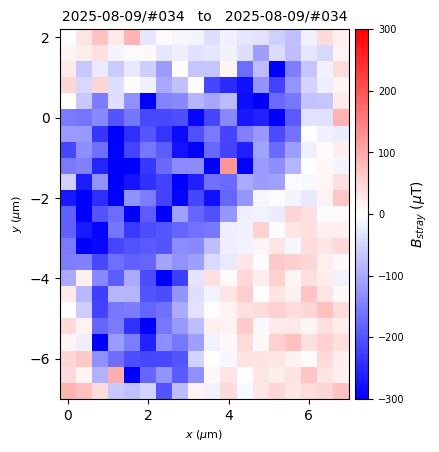

In [122]:
fig, ax = plt.subplots()

for j in range(ny):
    for i in range(nx):
        if dataPlot[j,i] < -2500:
            dataPlot[j,i] = dataPlot[j,i+1]
            # ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

plot = ax.pcolormesh(X,Y, dataPlot, cmap='bwr');
    
ax.set_aspect(1)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(plot, cax = cax)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('$B_{stray}$ ($\mu$T)', fontsize=10)
blim = 300
plot.set_clim(-blim,blim)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

fontsize=8
ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
sp = 0.025*conv_voltage

s = firstdatafile[31:46] + '   to   ' + datafile[31:46]
ax.set_title(s,fontsize=10)


plt.tight_layout;
Xoriginal = X; Yoriginal = Y; dataPlotOriginal = dataPlot
###############################################################################################

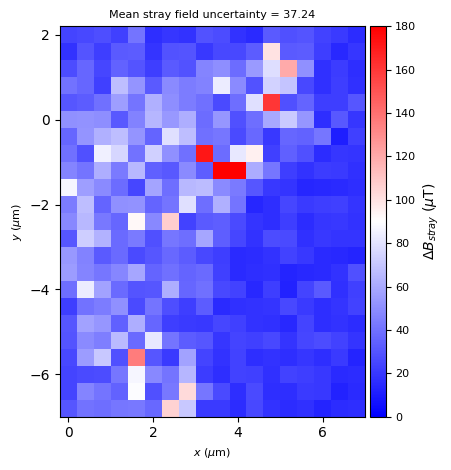

In [123]:
fig, ax = plt.subplots()
  
plot = ax.pcolormesh(X,Y, dataErr, cmap='bwr');
ax.set_aspect(1)

ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
plot.set_clim(0,180)
# ax.set_ylim((-9.5,20.5))

divider0 = make_axes_locatable(ax)
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
ax.set_title('Mean stray field uncertainty = %.2f' % (np.average(dataErr)), fontsize=fontsize)
ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.set_aspect(1)
cbar0 = plt.colorbar(plot, cax=cax0)
cbar0.ax.tick_params(labelsize=fontsize)
cbar0.set_label('$\Delta B_{stray}$ ($\mu$T)', fontsize=10)

plt.tight_layout()

### Calculate mean stray field

In [21]:
# Determine the UOTe boundary by some straight line

xmax1 = -0.8; ymax1 = 4.98; deltaY = 40
y1 = np.array((1.8, 4.2, 6.7))
x1 = np.array((3.5, 1.5, -0.5))

In [12]:
points = np.vstack([X.ravel(), Y.ravel()]).T
mask1 = (points[:, 0] <= xmax1) & (points[:, 1] <= ymax1) & (points[:, 1] >= ymax1-deltaY)
reg1 = points[mask1]

xfit, yfit, popt, perr = dr.fitLinear(x1,y1) 
a0 = popt[0]; b0 = popt[1]
mask2 = (points[:, 0] > xmax1) & (points[:, 1] <= a0*points[:, 0] + b0) & (points[:, 1] >= ymax1-deltaY)
reg2 = points[mask2]

uote = np.concatenate((reg1,reg2))

mask = mask1+mask2
mask2dErr = mask.reshape(np.shape(X))
print('Mean stray field uncertainty in UOTe = ' + str(np.average(dataErr[mask2dErr])))
print('Mean stray field uncertainty in BN = ' + str(np.average(dataErr[~mask2dErr])))


Mean stray field uncertainty in UOTe = 6.169307539442362
Mean stray field uncertainty in BN = 4.538628672712066


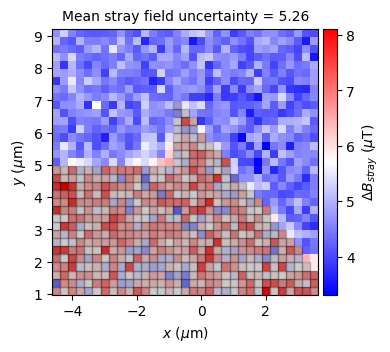

In [13]:
fig, ax = plt.subplots(figsize=(4,4))
  
plot = ax.pcolormesh(X,Y, dataErr, cmap='bwr');
ax.set_aspect(1)

ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)

divider0 = make_axes_locatable(ax)
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
ax.set_title('Mean stray field uncertainty = %.2f' % (np.average(dataErr)), fontsize=fontsize)
ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.set_aspect(1)
cbar0 = plt.colorbar(plot, cax=cax0)
cbar0.ax.tick_params(labelsize=fontsize)
cbar0.set_label('$\Delta B_{stray}$ ($\mu$T)', fontsize=10)

sp = 0.025*conv_voltage
for point in uote:
    ax.add_patch(plt.Rectangle((point[0]-sp/2, point[1]-sp/2), sp, sp, color='black',alpha=0.2))

plt.tight_layout()

# Smooth and filter

In [124]:
XBeforeShift = X; YBeforeShift = Y
thres=2500
for j in range(ny):
    for i in range(nx):
        if dataPlot[j,i] > thres:
            dataPlot[j,i] = dataPlot[j,i-1]

# Zero mean
x = X[0] - np.mean(X[0])
y = Y[:,0] - np.mean(Y[:,0])
xrecon_offset = 0; yrecon_offset = 0
Bscan = dataPlot.T

# Apply Gaussian filter for smoothing
size = 11; sigma = 0.5
Gfilter = np.zeros((size, size))
Gfilter[size//2, size//2] = 1  # Center pixel
Gfilter = gaussian_filter(Gfilter, sigma)
Bscan_conv1 = convolve2d(Bscan, Gfilter, mode='same')
Bscan = Bscan_conv1 # the Bscan version used for reconstruction

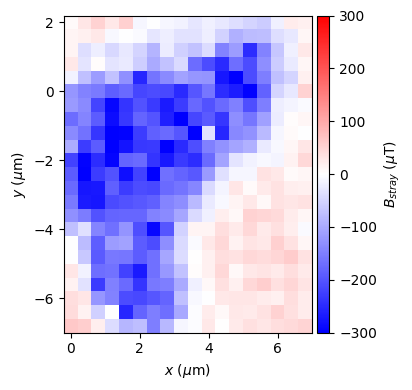

In [125]:
fontsize = 10; fig,ax = plt.subplots(figsize=(7,4))

X, Y = np.meshgrid(x, y)
im = ax.pcolormesh(XBeforeShift, YBeforeShift, Bscan.T, cmap='bwr')
clim = blim
# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('$B_{stray}$ ($\mu$T)', fontsize=fontsize)
im.set_clim((-clim, clim))
ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.set_aspect(1)

plt.tight_layout()

# Extend data

In [126]:
fastscan_ext = np.full(len(y) + 2, np.nan)
slowscan_ext = np.full(len(x) + 2, np.nan)

fastscan_ext[1:-1] = y - np.mean(y)
slowscan_ext[1:-1] = x - np.mean(x)

fastlen = len(y)
slowlen = len(x)

mtpFast = 6; mtpSlow = 6
fastscan_ext[0] = mtpFast * fastscan_ext[1]
fastscan_ext[-1] = mtpFast * fastscan_ext[-2]

slowscan_ext[0] = mtpSlow * slowscan_ext[1]
slowscan_ext[-1] = mtpSlow * slowscan_ext[-2]

itp_numfast = (fastlen - 1) * (mtpFast + 1)
itp_numslow = (slowlen - 1) * (mtpSlow + 1)

Bfield_extend = np.zeros((len(slowscan_ext), len(fastscan_ext)))
Bfield_extend[1:-1, 1:-1] = Bscan

fastintp = np.linspace(fastscan_ext[0], fastscan_ext[-1], itp_numfast)
slowintp = np.linspace(slowscan_ext[0], slowscan_ext[-1], itp_numslow)

X, Y  = np.meshgrid(slowscan_ext, fastscan_ext)#; X = X.T; Y= Y.T
Xi, Yi = np.meshgrid(slowintp, fastintp)#; Xi = Xi.T; Yi= Yi.T
# Bnv_intp = griddata((Y.flatten(), X.flatten()), Bfield_extend.T.flatten(),
#                     (Yi,Xi), method='linear')

# Bnv_intp = griddata((X.flatten(), Y.flatten()), Bfield_extend.T.flatten(),
#                     (Xi,Yi), method='linear')

interp_func = interp2d(slowscan_ext,fastscan_ext,Bfield_extend.T,kind='linear')
Bnv_intp = interp_func(slowintp, fastintp)

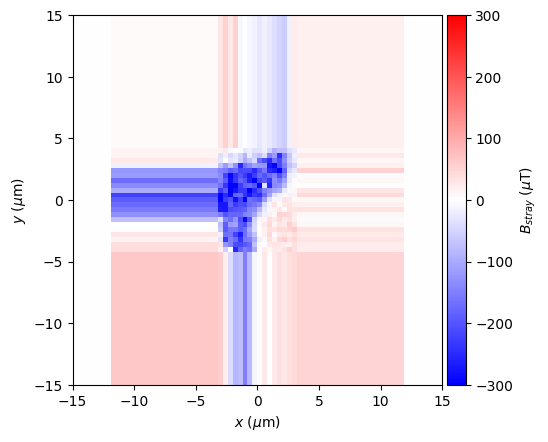

In [127]:
blim=clim
fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y,  Bfield_extend.T, cmap='bwr')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('$B_{stray}$ ($\mu$T)', fontsize=fontsize)
im.set_clim((-blim,blim))
ax.set_ylim((-15,15))
ax.set_xlim((-15,15))
ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.set_aspect(1)

# Reconstruct Bz, Bx, By

In [128]:
thetaNV = np.arccos(1/np.sqrt(3))
phiNV = pi/2-0*np.arcsin(1/3)
rx_inv, ry_inv, BZ_map, BX_map, BY_map = Reconstruction_StrayOUTpl_v2(
    slowintp, fastintp, Bnv_intp, thetaNV, phiNV)

# rx_inv = rx_inv - xrecon_offset
xrangecut = (rx_inv >= slowscan_ext[1]) & (rx_inv <= slowscan_ext[-2])
yrangecut = (ry_inv >= fastscan_ext[1]) & (ry_inv <= fastscan_ext[-2])
rx_inv = rx_inv[xrangecut]; rx_inv = rx_inv - xrecon_offset
ry_inv = ry_inv[yrangecut]; ry_inv = ry_inv - yrecon_offset
BX_map = BX_map[yrangecut][:, xrangecut]
BY_map = BY_map[yrangecut][:, xrangecut]
BZ_map = BZ_map[yrangecut][:, xrangecut]

C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_39888\2034141980.py:13: RuntimeWarning: invalid value encountered in divide
  FfactX = 1j * (kXres / Ktot)  # i*cos
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_39888\2034141980.py:14: RuntimeWarning: invalid value encountered in divide
  FfactY = 1j * (kYres / Ktot)  # i*sin


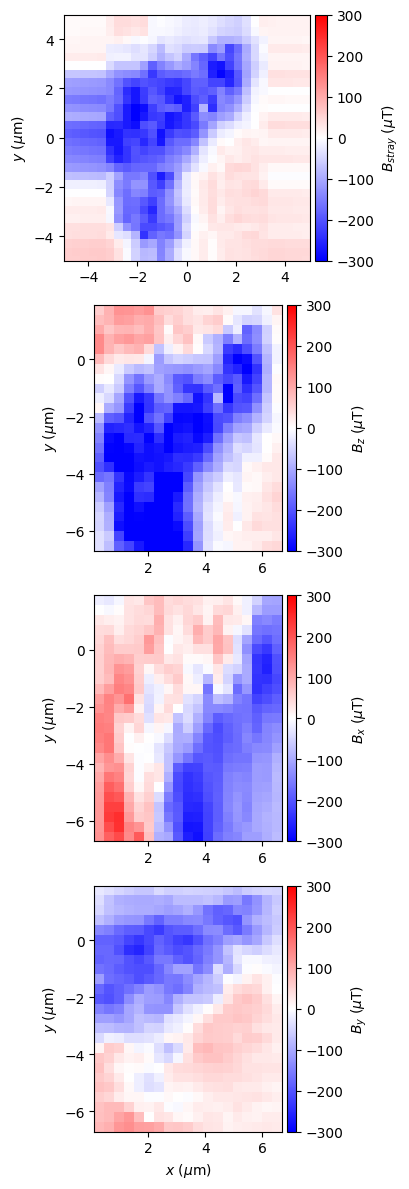

In [129]:
fontsize = 10; exag = 1
fig,axs = plt.subplots(4,1,figsize=(7,12))
im = axs[0].pcolormesh(Xi, Yi, Bnv_intp**exag, cmap='bwr')

# Create a divider for the existing axes instance
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('$B_{stray}$ ($\mu$T)', fontsize=fontsize)
im.set_clim((-blim**exag,blim**exag))
axs[0].set_ylabel('y (V)')
axs[0].set_ylim((-5,5))
axs[0].set_xlim((-5,5))

xplot = rx_inv + np.mean(XBeforeShift[0])
yplot = ry_inv + np.mean(YBeforeShift[:,0])
X, Y = np.meshgrid(xplot,yplot)
im1 = axs[1].pcolormesh(X, Y,  BZ_map**exag, cmap='bwr')
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
cbar1 = plt.colorbar(im1, cax=cax1)
cbar1.ax.tick_params(labelsize=fontsize)
cbar1.set_label('$B_{z}$ ($\mu$T)', fontsize=fontsize)
im1.set_clim((-blim**exag,blim**exag))
# axs[1].set_ylim((-4.25, -0.05))

im2 = axs[2].pcolormesh(X, Y,  BX_map, cmap='bwr')
divider2 = make_axes_locatable(axs[2])
cax2 = divider2.append_axes("right", size="5%", pad=0.05)
cbar2 = plt.colorbar(im2, cax=cax2)
cbar2.ax.tick_params(labelsize=fontsize)
cbar2.set_label('$B_{x}$ ($\mu$T)', fontsize=fontsize)
im2.set_clim((-blim,blim))


im3 = axs[3].pcolormesh(X, Y,  BY_map, cmap='bwr')
divider3 = make_axes_locatable(axs[3])
cax3 = divider3.append_axes("right", size="5%", pad=0.05)
cbar3 = plt.colorbar(im3, cax=cax3)
cbar3.ax.tick_params(labelsize=fontsize)
cbar3.set_label('$B_{y}$ ($\mu$T)', fontsize=fontsize)
im3.set_clim((-blim,blim))
axs[3].set_xlabel('$x$ ($\mu$m)')

for i in range(4):
    axs[i].set_aspect(1)
    axs[i].set_ylabel('$y$ ($\mu$m)')
    # if i>0:
    #     axs[i].set_xlim((-7,0))
    #     axs[i].set_ylim((-1.7,2.5))

plt.tight_layout()

# Print

In [43]:
# print('Bz average = ' + str(np.average(BZ_map[:,7:])))
# print('Berr average = ' + str(np.average(dataErr[:,7:])))

# Reconstruct Mz

C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_39888\519550328.py:9: RuntimeWarning: invalid value encountered in divide
  FfactX = 1j * (kXres / Ktot)  # i*cos
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_39888\519550328.py:10: RuntimeWarning: invalid value encountered in divide
  FfactY = 1j * (kYres / Ktot)  # i*sin


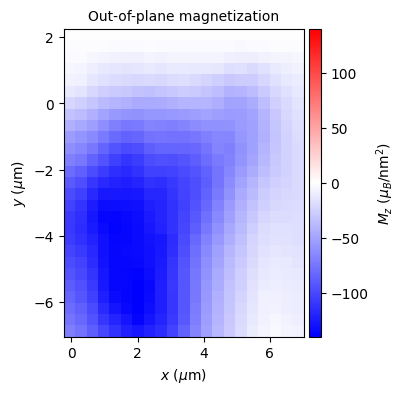

In [134]:
if True:
    hNV = 40e-3  # in units of um;
    thickness = 10e-3

    # Reconstruct current distribution
    rx_inv2, ry_inv2, SigZout, Dzz = Recreate_m_inplane_from_field(
        (slowintp*1), (fastintp*1), Bnv_intp*1e-6, hNV, thetaNV, phiNV, thickness)

    # Apply range cuts
    extra = 0.1
    xrangecut2 = (rx_inv2 >= slowscan_ext[1]-extra) & (rx_inv2 <= slowscan_ext[-2]+extra)
    yrangecut2 = (ry_inv2 >= fastscan_ext[1]-extra) & (ry_inv2 <= fastscan_ext[-2]+extra)

    rx_inv_cut = rx_inv2[xrangecut2] - xrecon_offset
    ry_inv_cut = ry_inv2[yrangecut2] - yrecon_offset
    SigZout = SigZout[yrangecut2][:, xrangecut2]

    xplot = rx_inv_cut + np.mean(XBeforeShift[0]); yplot = ry_inv_cut + np.mean(YBeforeShift[:,0])
    X, Y = np.meshgrid(xplot,yplot)

    xfit, yfit, popt, perr = dr.fitLinear(X[0], np.average(SigZout[-1:,],axis=0)) 
    bkgM = SigZout[-1] #dr.linear(X[0], *popt)
    bkgM = np.broadcast_to(bkgM, (len(Y[:,0]), len(X[0])))
    SigZout = SigZout - bkgM

    # Convert to appropriate units
    muB = ee * hbar / (2 * me)
    mz = SigZout*1e-18*(thickness*1e-6) / muB

# Plotting
if True:
    fig,ax = plt.subplots(figsize=(7,4))
    im0 = ax.pcolormesh(X, Y,  mz**exag, cmap='bwr')
    divider0 = make_axes_locatable(ax)
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    ax.set_title('Out-of-plane magnetization', fontsize=fontsize)
    ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
    ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
    ax.set_aspect(1)
    cbar0 = plt.colorbar(im0, cax=cax0)
    cbar0.ax.tick_params(labelsize=fontsize)
    cbar0.set_label(r'$M_z$ ($\mu_B$/nm$^2$)', fontsize=fontsize)
    
    clim = 140
    im0.set_clim((-clim,clim))
    # im0.set_cmap('seismic')


if False: #xmax1, ymax1, a0, b0 are defined earlier in the error plot
    points = np.vstack([X.ravel(), Y.ravel()]).T
    mask1 = (points[:, 0] <= xmax1) & (points[:, 1] <= ymax1) & (points[:, 1] >= ymax1-deltaY)
    mask2 = (points[:, 0] > xmax1) & (points[:, 1] <= a0*points[:, 0] + b0) & (points[:, 1] >= ymax1-deltaY)
    mask = mask1 + mask2
    uote = points[mask]

    sp = (Y[2,0]-Y[1,0] + X[0,2]-X[0,1])/2
    for point in uote:
        ax.add_patch(plt.Rectangle((point[0]-sp/2, point[1]-sp/2), sp, sp, color='black',alpha=0.1))
    plt.tight_layout()

    mask2d = mask.reshape(np.shape(X))


## Save data for manuscript plot

In [ ]:
# # Save as npz file, and test loading back
# np.savez('C:/Users/lukin2dmaterials/data/forUOTeManuscript/X_Y_Mz.npz', X=X, Y=Y, Mz=mz**exag)
# time.sleep(1)
# data = np.load('C:/Users/lukin2dmaterials/data/forUOTeManuscript/X_Y_Mz.npz')
# a = data['X']
# b = data['Y']
# c = data['Mz']

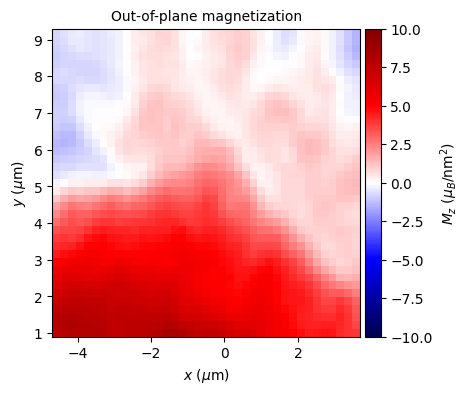

In [ ]:
# fig,ax = plt.subplots(figsize=(7,4))
# im0 = ax.pcolormesh(a,b,c, cmap='bwr')
# divider0 = make_axes_locatable(ax)
# cax0 = divider0.append_axes("right", size="5%", pad=0.05)
# ax.set_title('Out-of-plane magnetization', fontsize=fontsize)
# ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
# ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)
# ax.set_aspect(1)
# cbar0 = plt.colorbar(im0, cax=cax0)
# cbar0.ax.tick_params(labelsize=fontsize)
# cbar0.set_label(r'$M_z$ ($\mu_B$/nm$^2$)', fontsize=fontsize)

# im0.set_clim((-10,10)); im0.set_cmap('seismic')

In [ ]:
# # Save as csv
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/mzplot_X.csv', X)
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/mzplot_Y.csv', Y)
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/mzplot_Mz.csv', mz**exag)

## Avg with error bar

In [22]:
print('Mean Mz in UOTe = ' + str(np.average(mz[mask2d])))
print('Mean Mz in BN = ' + str(np.average(mz[~mask2d])))
print('Err in BN = ' + str(np.average(dataErr[~mask2dErr])))

Mean Mz in UOTe = 4.668041654433778
Mean Mz in BN = 0.3816890567291178
Err in BN = 4.538628672712066


## Bstray

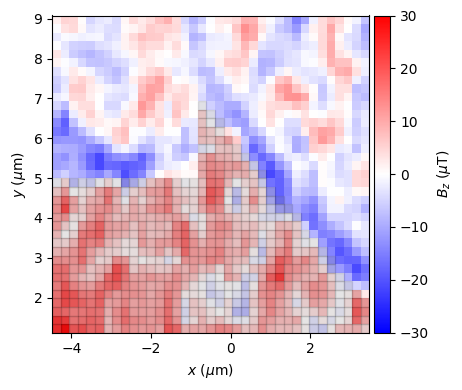

In [23]:
fig, ax = plt.subplots(figsize=(7,4))

if True:
    xplot = rx_inv + np.mean(XBeforeShift[0])
    yplot = ry_inv + np.mean(YBeforeShift[:,0])
    X, Y = np.meshgrid(xplot,yplot)
    im1 = ax.pcolormesh(X, Y,  BZ_map**exag, cmap='bwr')
    divider1 = make_axes_locatable(ax)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    cbar1 = plt.colorbar(im1, cax=cax1)
    cbar1.ax.tick_params(labelsize=fontsize)
    cbar1.set_label('$B_{z}$ ($\mu$T)', fontsize=fontsize)
    im1.set_clim((-blim**exag,blim**exag))
    ax.set_aspect(1)

    ax.set_xlabel('$x$ ($\mu$m)', fontsize=fontsize)
    ax.set_ylabel('$y$ ($\mu$m)', fontsize=fontsize)

if True: #xmax1, ymax1, a0, b0 are defined earlier in the error plot
    points = np.vstack([X.ravel(), Y.ravel()]).T
    mask1 = (points[:, 0] <= xmax1) & (points[:, 1] <= ymax1) & (points[:, 1] >= ymax1-deltaY) 
    mask2 = (points[:, 0] > xmax1) & (points[:, 1] <= a0*points[:, 0] + b0) & (points[:, 1] >= ymax1-deltaY) 
    mask = mask1 + mask2
    uote = points[mask]

    sp = (Y[2,0]-Y[1,0] + X[0,2]-X[0,1])/2
    for point in uote:
        ax.add_patch(plt.Rectangle((point[0]-sp/2, point[1]-sp/2), sp, sp, color='black',alpha=0.1))
    plt.tight_layout()

    mask2d = mask.reshape(np.shape(X))

plt.tight_layout()

In [24]:
Berr_denom = np.sum(1/dataErr[mask2dErr]**2)
Berr_numer = np.sum(dataPlot[mask2dErr]/dataErr[mask2dErr]**2)
weightedB = Berr_numer/Berr_denom
weightedErr = np.sqrt(1/Berr_denom)

print('<Bstray> in UOTe = ' + str(weightedB))
print('Std of the mean of Bstray in UOTe = ' + str(weightedErr))
print('Std of Bstray in UOTe = ' + str(np.std(dataPlot[mask2dErr])))
print('Average of fit error in UOTe = ' + str(np.average(dataErr[mask2dErr])))
print('<Bz> in UOTe = ' + str(np.average(BZ_map[mask2d])))


<Bstray> in UOTe = 11.009760169473793
Std of the mean of Bstray in UOTe = 0.27530251388911076
Std of Bstray in UOTe = 7.468880374765743
Average of fit error in UOTe = 6.169307539442362
<Bz> in UOTe = 6.844702338643735


## Save data for manuscript plot

In [ ]:
# # Save as npz file, and test loading back
# np.savez('C:/Users/lukin2dmaterials/data/forUOTeManuscript/X_Y_PL.npz', X=X, Y=Y, PL=cfc[start:end,start:end])
# time.sleep(1)
# data = np.load('C:/Users/lukin2dmaterials/data/forUOTeManuscript/X_Y_PL.npz')
# a = data['X']
# b = data['Y']
# c = data['PL']

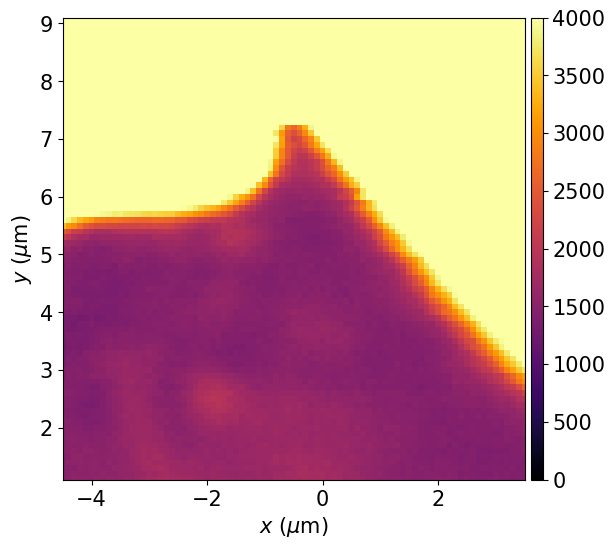

In [47]:
fig, ax = plt.subplots(figsize=(6,6))
fontsize = 15; convfactor = 10
start = 0; end = None
X,Y = np.meshgrid(x_array[start:end]*convfactor, y_array[start:end]*convfactor)
im = ax.pcolormesh(a,b,c, cmap='inferno')
ax.set_aspect(1)
im.set_clim([0,4000])

plt.xlabel('$x$ ($\mu$m)', fontsize=fontsize)
plt.ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)

ax.set_xlim((-4.5,3.5))
ax.set_ylim((1.1,9.1))

cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(im, cax = cax)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
# # Save as csv
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/PLplot_X.csv', X)
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/PLplot_Y.csv', Y)
# np.savetxt('C:/Users/lukin2dmaterials/data/forUOTeManuscript/PLplot_PL.csv', cfc[start:end,start:end])